In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day5_standardized_supply_data.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/day6_unit_normalized_data.csv"

In [4]:
df = pd.read_csv(INPUT_FILE)
print("Dataset loaded:", df.shape)

# normalize units

df["unit"] = df["unit"].replace({
    "kg": "kg",
    "kilogram": "kg",
    "kilograms": "kg"
})

Dataset loaded: (10257, 8)


In [6]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
print("Missing quantity values:", df["quantity"].isnull().sum())

Missing quantity values: 0


In [7]:
# total_procurement_cost = quantity × cost_per_kg

df["total_procurement_cost"] = df["quantity"] * df["cost_per_kg"]

In [8]:
#Calculate shipment volume per supplier.

vendor_volume = df.groupby("vendor_name")["quantity"].sum()

vendor_volume.to_csv(
    PROJECT_ROOT / "03_processed_data/vendor_total_quantity.csv"
)

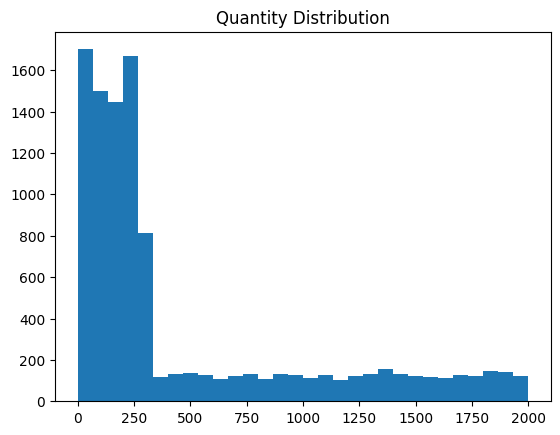

In [11]:
plt.hist(df["quantity"], bins=30)
plt.title("Quantity Distribution")
plt.show()
plt.savefig(PROJECT_ROOT / "04_visualizations/quantity_distribution.png")
plt.close()

batch_id                    0
vendor_name                 0
product_name                0
quantity                    0
unit                        0
cost_per_kg               205
defect_rate_pct             0
procurement_date            0
total_procurement_cost    205
dtype: int64
